In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [6]:
df = pd.read_excel('../Day1_ETL_Data_Integration/Cleaned_Car_Data.xlsx', sheet_name='Cleaned_Data')
print(df.shape)
df.head()

(98, 11)


,Car_Name,Year,Selling_Price_Lakhs,Present_Price_Lakhs,Kms_Driven_KM,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age,Depreciation_Percentage
0,Ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,10,40.07
1,Sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,11,50.21
2,Ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,7,26.40
3,Wagon R,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,13,31.33
4,Swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,10,33.04


In [7]:
print("=== Summary Statistics ===")
print(df.describe())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Skewness ===")
print(df.select_dtypes(include=np.number).skew())

print("\n=== Kurtosis ===")
print(df.select_dtypes(include=np.number).kurtosis())

=== Summary Statistics ===
              Year  Selling_Price_Lakhs  Present_Price_Lakhs  Kms_Driven_KM  \
count    98.000000            98.000000            98.000000      98.000000   
mean   2013.744898             2.701735             4.837929   28602.316327   
std       3.110711             4.578110            10.379531   28012.317507   
min    2003.000000             0.180000             0.320000     500.000000   
25%    2012.000000             0.450000             0.732500    7250.000000   
50%    2014.500000             0.925000             1.230000   23085.500000   
75%    2016.000000             3.537500             6.815000   39263.750000   
max    2018.000000            35.000000            92.600000  142000.000000   

           Owner    Car_Age  Depreciation_Percentage  
count  98.000000  98.000000                98.000000  
mean    0.091837  10.255102                35.545000  
std     0.382254   3.110711                21.244723  
min     0.000000   6.000000              

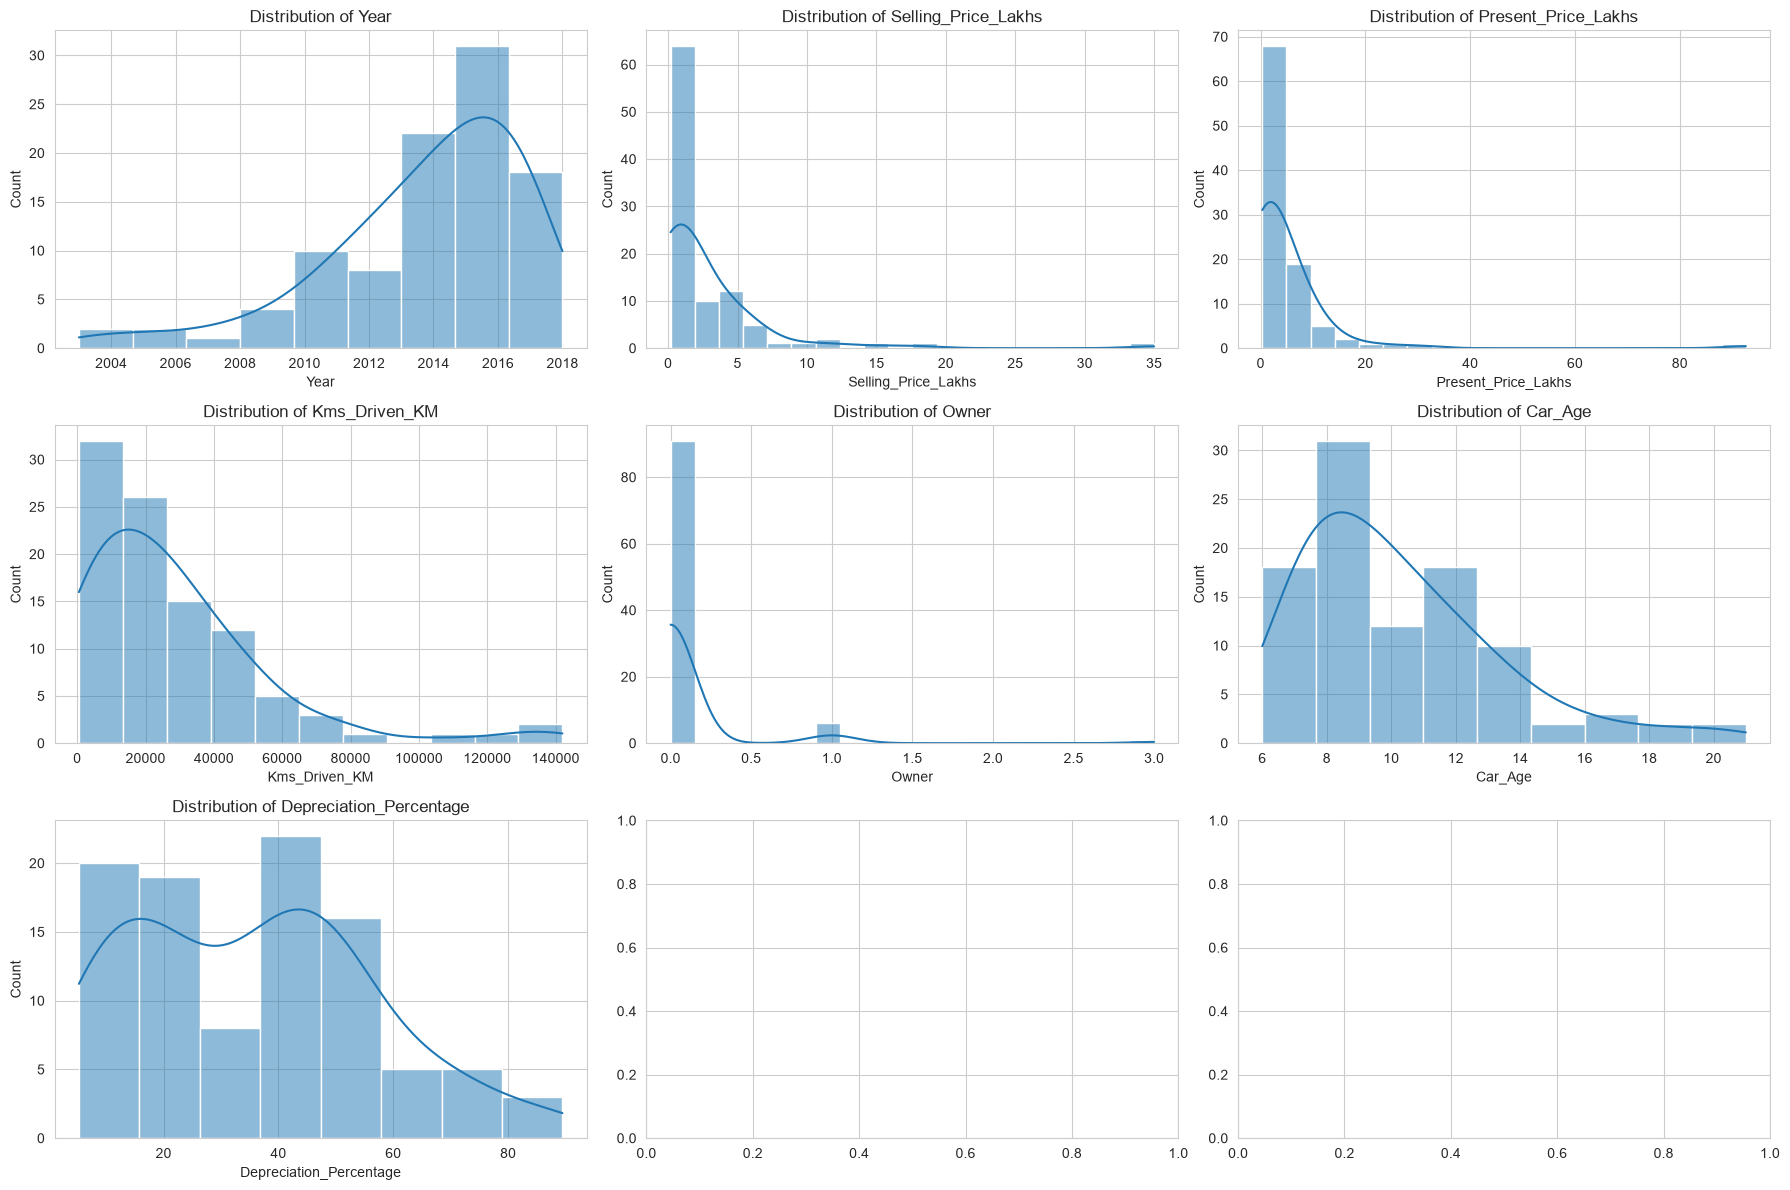

In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns

fig, axes = plt.subplots(nrows=(len(numeric_cols)//3)+1, ncols=3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

Year: 3 outliers (bounds: 2006.00 to 2022.00)
Selling_Price_Lakhs: 6 outliers (bounds: -4.18 to 8.17)
Present_Price_Lakhs: 4 outliers (bounds: -8.39 to 15.94)
Kms_Driven_KM: 4 outliers (bounds: -40770.62 to 87284.38)
Owner: 7 outliers (bounds: 0.00 to 0.00)
Car_Age: 3 outliers (bounds: 2.00 to 18.00)
Depreciation_Percentage: 0 outliers (bounds: -32.90 to 101.00)


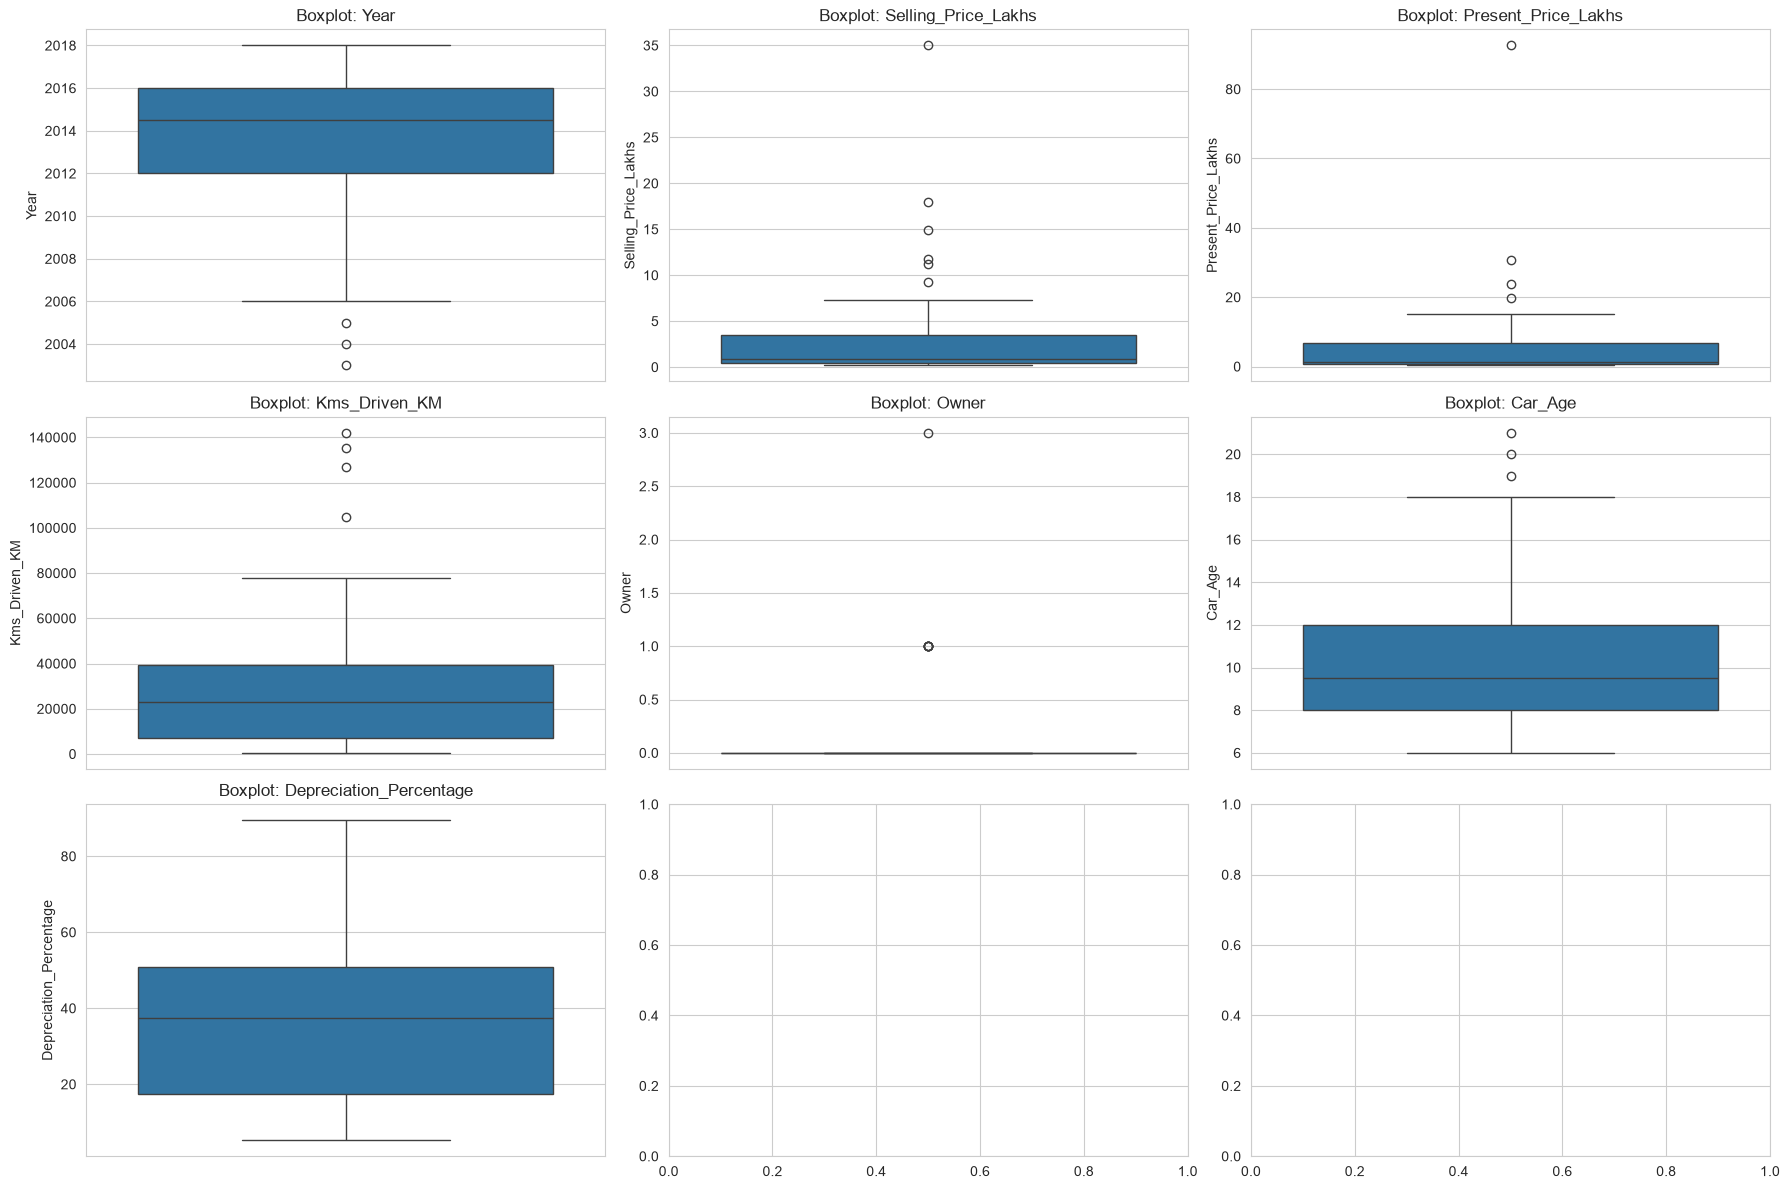

In [9]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower) | (data[column] > upper)]
    return outliers, lower, upper

outlier_summary = {}
for col in numeric_cols:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    outlier_summary[col] = len(outliers)
    print(f"{col}: {len(outliers)} outliers (bounds: {lower:.2f} to {upper:.2f})")

fig, axes = plt.subplots(nrows=(len(numeric_cols)//3)+1, ncols=3, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

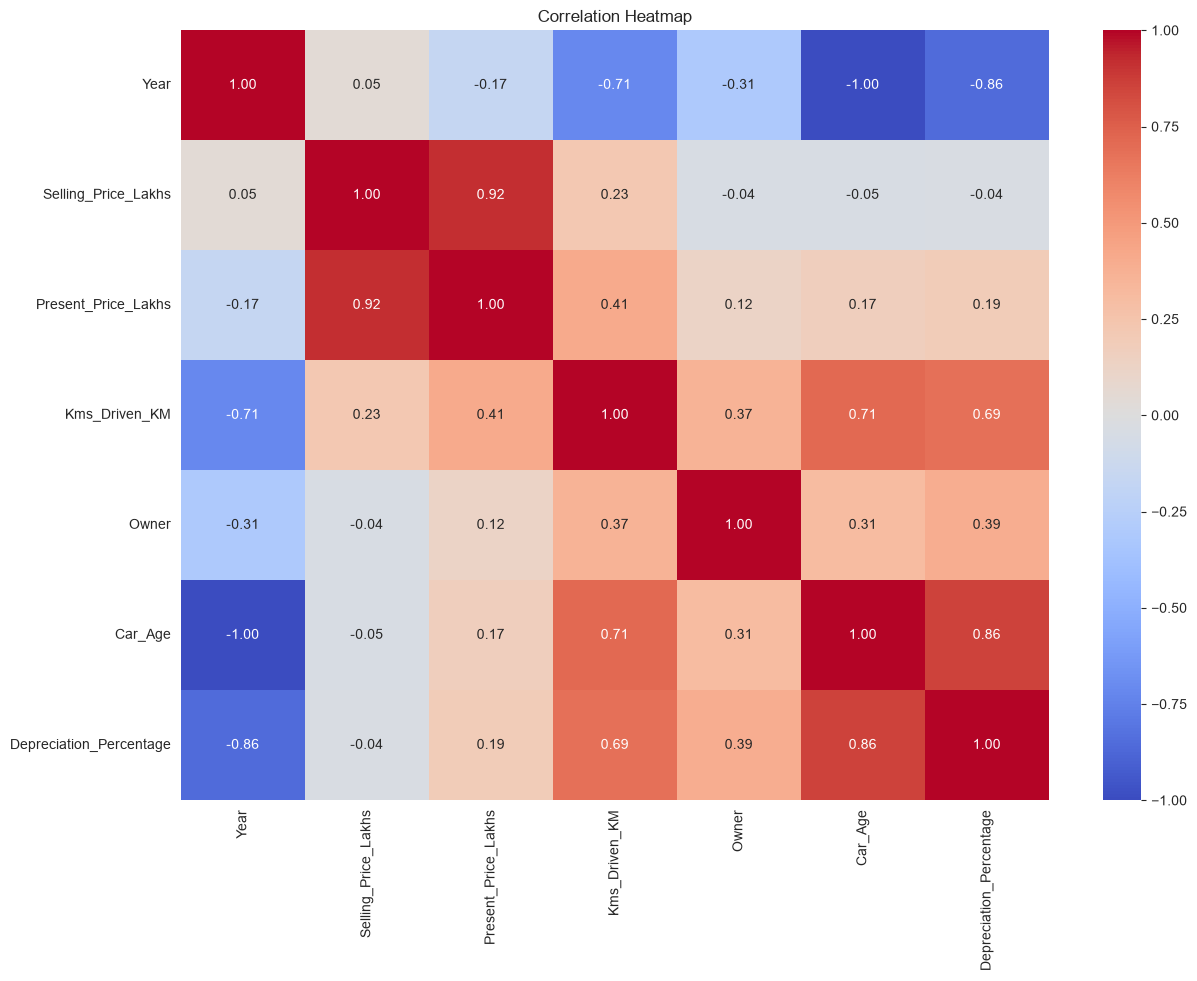

Selling_Price_Lakhs        1.000000
Present_Price_Lakhs        0.915368
Kms_Driven_KM              0.226359
Year                       0.046151
Depreciation_Percentage   -0.035842
Owner                     -0.044275
Car_Age                   -0.046151
Name: Selling_Price_Lakhs, dtype: float64


In [10]:
plt.figure(figsize=(14, 10))
corr_matrix = df[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

print(corr_matrix['Selling_Price_Lakhs'].sort_values(ascending=False))

C:\Users\lenono\AppData\Local\Temp\ipykernel_17148\2145236476.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


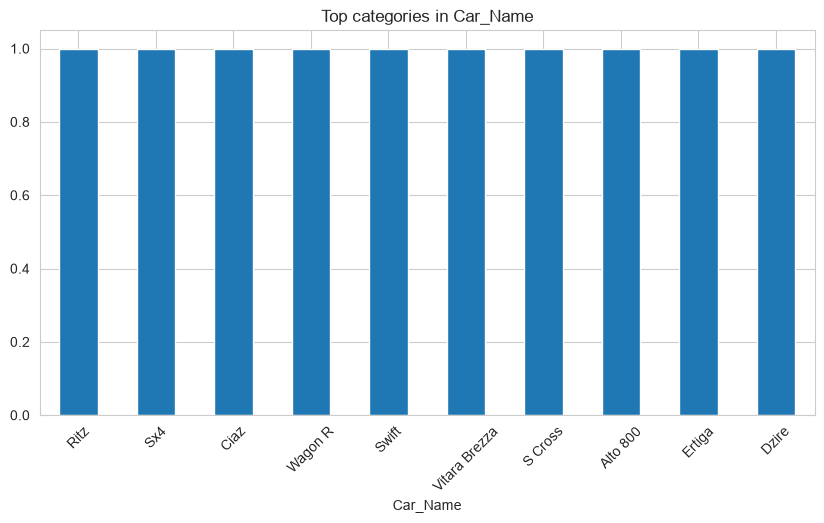

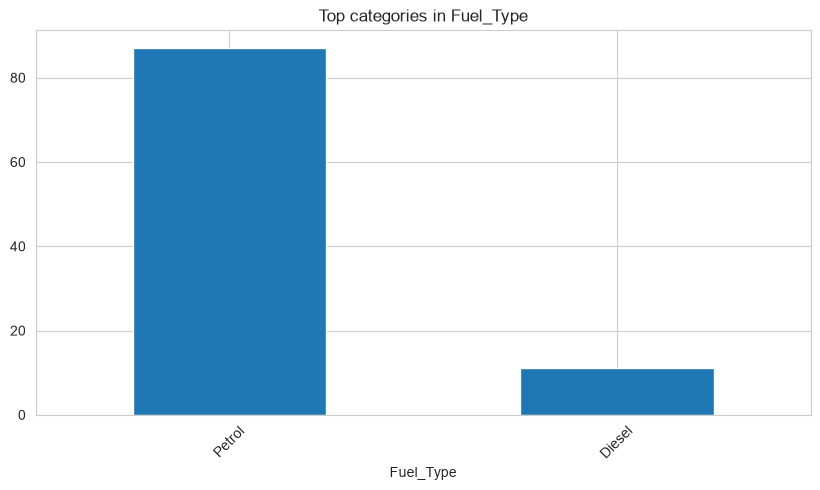

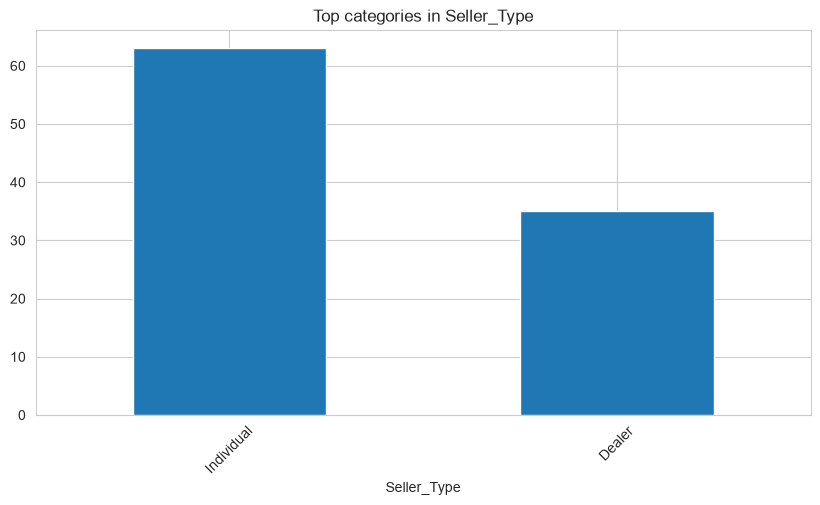

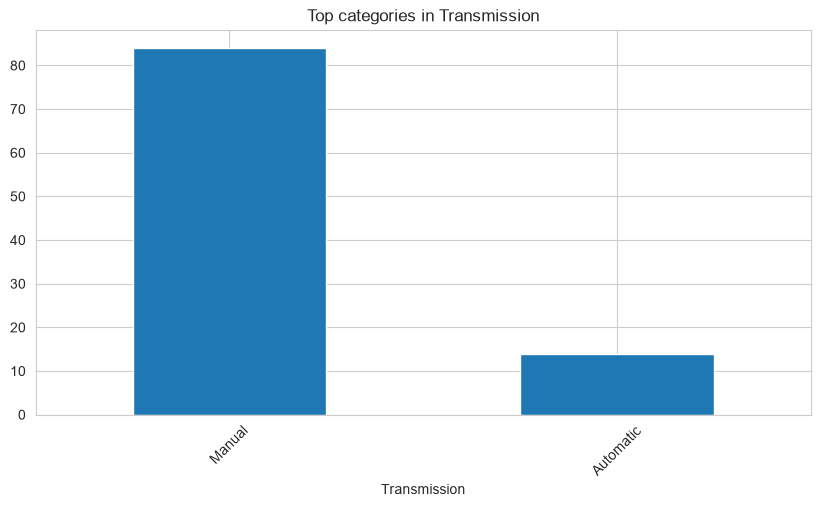

In [11]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(10, 5))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f'Top categories in {col}')
    plt.xticks(rotation=45)
    plt.show()

In [12]:
print("""
EDA KEY INSIGHTS
================
1. Dataset shape: {} rows, {} columns
2. Most skewed feature: {}
3. Column with most outliers: {}
4. Strongest correlation with Selling Price: see heatmap above
5. Most common fuel type: {}
""".format(
    df.shape[0], df.shape[1],
    df.select_dtypes(include=np.number).skew().idxmax(),
    max(outlier_summary, key=outlier_summary.get),
    df['Fuel_Type'].mode()[0] if 'Fuel_Type' in df.columns else 'N/A'
))


EDA KEY INSIGHTS
1. Dataset shape: 98 rows, 11 columns
2. Most skewed feature: Present_Price_Lakhs
3. Column with most outliers: Owner
4. Strongest correlation with Selling Price: see heatmap above
5. Most common fuel type: Petrol

